In [1]:
import pandas as pd
import numpy as np
import re
import nltk
import spacy
import matplotlib.pyplot as plt
from wordcloud import WordCloud

nltk.download('stopwords')
nlp = spacy.load('en_core_web_sm')

print("All libraries loaded successfully!")


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


All libraries loaded successfully!


In [2]:
cols = ['sentiment', 'id', 'date', 'query', 'user', 'text']

df = pd.read_csv('../data/raw/training.1600000.processed.noemoticon.csv',
                 encoding='latin-1',
                 names=cols)

df['sentiment'] = df['sentiment'].map({0: 0, 4: 1})

print("Shape:", df.shape)
print(df['sentiment'].value_counts())

Shape: (1600000, 6)
sentiment
0    800000
1    800000
Name: count, dtype: int64


In [3]:
df[['sentiment', 'text']].head(5)

,sentiment,text
0,0,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,is upset that he can't update his Facebook by ...
2,0,@Kenichan I dived many times for the ball. Man...
3,0,my whole body feels itchy and like its on fire
4,0,"@nationwideclass no, it's not behaving at all...."


In [4]:
df = df.sample(n=100000, random_state=42).reset_index(drop=True)
print("Working sample shape:", df.shape)

Working sample shape: (100000, 6)


In [5]:
import re

def clean_tweet(text):
    text = text.lower()                           # lowercase everything
    text = re.sub(r'http\S+|www\S+', '', text)   # remove URLs
    text = re.sub(r'@\w+', '', text)             # remove @mentions
    text = re.sub(r'#(\w+)', r'\1', text)        # remove # but keep word
    text = re.sub(r'[^a-z\s]', '', text)         # remove numbers & symbols
    text = re.sub(r'\s+', ' ', text).strip()     # remove extra spaces
    return text

# Test on 3 sample tweets first
sample = df['text'].head(3).values
for tweet in sample:
    print("BEFORE:", tweet)
    print("AFTER: ", clean_tweet(tweet))
    print()

BEFORE: @chrishasboobs AHHH I HOPE YOUR OK!!! 
AFTER:  ahhh i hope your ok

BEFORE: @misstoriblack cool , i have no tweet apps  for my razr 2
AFTER:  cool i have no tweet apps for my razr

BEFORE: @TiannaChaos i know  just family drama. its lame.hey next time u hang out with kim n u guys like have a sleepover or whatever, ill call u
AFTER:  i know just family drama its lamehey next time u hang out with kim n u guys like have a sleepover or whatever ill call u



In [6]:
df['clean_text'] = df['text'].apply(clean_tweet)
print("Cleaning done!")
print(df[['text', 'clean_text']].head(3))

Cleaning done!
                                                text  \
0             @chrishasboobs AHHH I HOPE YOUR OK!!!    
1  @misstoriblack cool , i have no tweet apps  fo...   
2  @TiannaChaos i know  just family drama. its la...   

                                          clean_text  
0                                ahhh i hope your ok  
1              cool i have no tweet apps for my razr  
2  i know just family drama its lamehey next time...  


In [7]:
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

def lemmatize(text):
    doc = nlp(text)
    return ' '.join([token.lemma_ for token in doc
                     if not token.is_stop and token.is_alpha])

# Test on 3 samples first
for text in df['clean_text'].head(3).values:
    print("BEFORE:", text)
    print("AFTER: ", lemmatize(text))
    print()

BEFORE: ahhh i hope your ok
AFTER:  ahhh hope ok

BEFORE: cool i have no tweet apps for my razr
AFTER:  cool tweet app razr

BEFORE: i know just family drama its lamehey next time u hang out with kim n u guys like have a sleepover or whatever ill call u
AFTER:  know family drama lamehey time u hang kim n u guy like sleepover ill u



In [8]:
print("Starting lemmatization... this will take a few minutes")
df['lemma_text'] = df['clean_text'].apply(lemmatize)
print("Lemmatization done!")
print(df[['text', 'clean_text', 'lemma_text']].head(3))

Starting lemmatization... this will take a few minutes
Lemmatization done!
                                                text  \
0             @chrishasboobs AHHH I HOPE YOUR OK!!!    
1  @misstoriblack cool , i have no tweet apps  fo...   
2  @TiannaChaos i know  just family drama. its la...   

                                          clean_text  \
0                                ahhh i hope your ok   
1              cool i have no tweet apps for my razr   
2  i know just family drama its lamehey next time...   

                                          lemma_text  
0                                       ahhh hope ok  
1                                cool tweet app razr  
2  know family drama lamehey time u hang kim n u ...  


In [9]:
df.to_csv('../data/processed/cleaned_tweets.csv', index=False)
print("Saved to data/processed/cleaned_tweets.csv ✅")

Saved to data/processed/cleaned_tweets.csv ✅


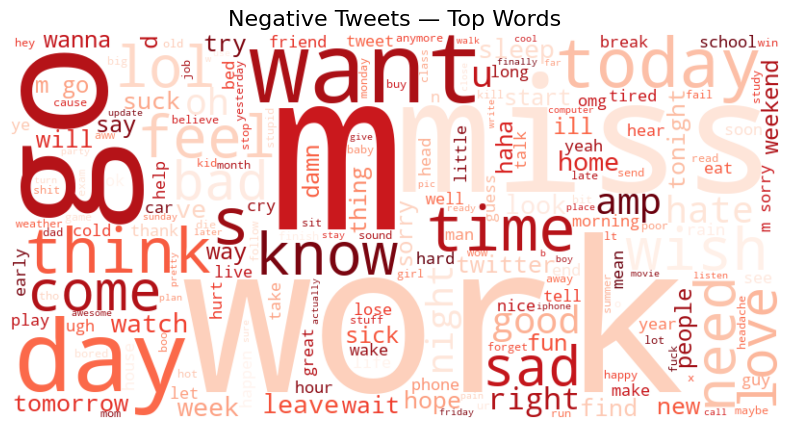

Negative WordCloud saved! ✅


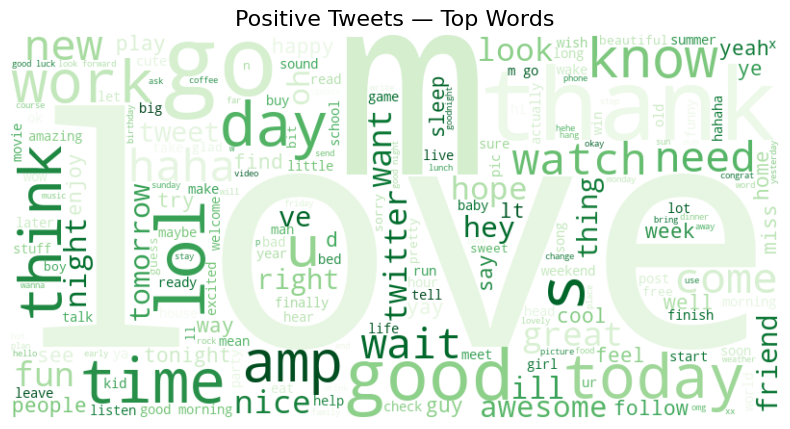

Positive WordCloud saved! ✅


In [10]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

for label, name in [(0, 'Negative'), (1, 'Positive')]:
    text = ' '.join(df[df['sentiment'] == label]['lemma_text'])
    
    wc = WordCloud(width=800, height=400, 
                   background_color='white',
                   colormap='Reds' if label == 0 else 'Greens'
                   ).generate(text)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'{name} Tweets — Top Words', fontsize=16)
    plt.savefig(f'../outputs/wordcloud_{name}.png', bbox_inches='tight')
    plt.show()
    print(f"{name} WordCloud saved! ✅")

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import joblib

print("All Week 2 libraries imported! ✅")

All Week 2 libraries imported! ✅


In [12]:
# Load cleaned data
df = pd.read_csv('../data/processed/cleaned_tweets.csv')

# Drop any empty rows
df = df.dropna(subset=['lemma_text'])

# Define X (input) and y (output)
X = df['lemma_text']
y = df['sentiment']

# Split 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Training size:", len(X_train))
print("Testing size: ", len(X_test))
print("Ready to train! ✅")


Training size: 79469
Testing size:  19868
Ready to train! ✅


In [13]:
tfidf = TfidfVectorizer(max_features=50000, ngram_range=(1,2))

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF shape (train):", X_train_tfidf.shape)
print("TF-IDF shape (test): ", X_test_tfidf.shape)
print("Vectorization done! ✅")

TF-IDF shape (train): (79469, 50000)
TF-IDF shape (test):  (19868, 50000)
Vectorization done! ✅


In [14]:
print("Training Logistic Regression... please wait")

lr_model = LogisticRegression(max_iter=1000, C=1.0)
lr_model.fit(X_train_tfidf, y_train)

# Test it
lr_pred = lr_model.predict(X_test_tfidf)

# Measure accuracy
lr_accuracy = accuracy_score(y_test, lr_pred)
lr_f1 = f1_score(y_test, lr_pred)

print(f"Logistic Regression Accuracy: {lr_accuracy:.4f}")
print(f"Logistic Regression F1 Score: {lr_f1:.4f}")
print("Training done! ✅")

Training Logistic Regression... please wait
Logistic Regression Accuracy: 0.7658
Logistic Regression F1 Score: 0.7703
Training done! ✅


In [15]:
print("Training Naïve Bayes... please wait")

nb_model = MultinomialNB(alpha=0.1)
nb_model.fit(X_train_tfidf, y_train)

# Test it
nb_pred = nb_model.predict(X_test_tfidf)

# Measure accuracy
nb_accuracy = accuracy_score(y_test, nb_pred)
nb_f1 = f1_score(y_test, nb_pred)

print(f"Naïve Bayes Accuracy: {nb_accuracy:.4f}")
print(f"Naïve Bayes F1 Score: {nb_f1:.4f}")
print("Training done! ✅")

Training Naïve Bayes... please wait
Naïve Bayes Accuracy: 0.7398
Naïve Bayes F1 Score: 0.7386
Training done! ✅


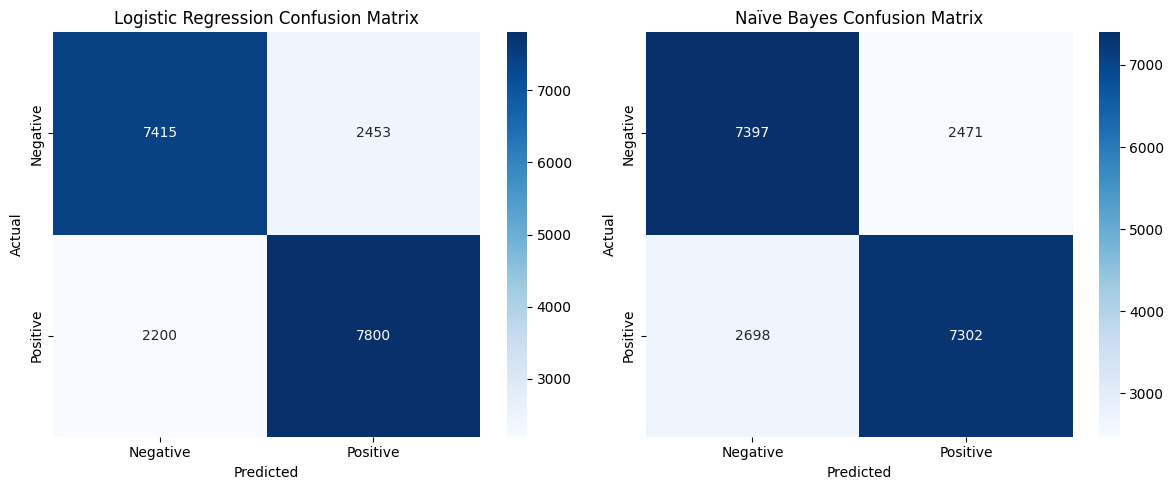

Confusion Matrix saved! ✅


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, pred, title in zip(axes,
                            [lr_pred, nb_pred],
                            ['Logistic Regression', 'Naïve Bayes']):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'])
    ax.set_title(f'{title} Confusion Matrix')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('../outputs/confusion_matrix.png', bbox_inches='tight')
plt.show()
print("Confusion Matrix saved! ✅")

In [17]:
# Save models to models/ folder
joblib.dump(lr_model, '../models/logistic_regression_model.pkl')
joblib.dump(nb_model, '../models/naive_bayes_model.pkl')
joblib.dump(tfidf, '../models/tfidf_vectorizer.pkl')

print("Logistic Regression saved! ✅")
print("Naïve Bayes saved! ✅")
print("TF-IDF Vectorizer saved! ✅")

Logistic Regression saved! ✅
Naïve Bayes saved! ✅
TF-IDF Vectorizer saved! ✅


In [18]:
# Test with custom tweets
def predict_sentiment(tweet):
    cleaned = tweet.lower()
    vectorized = tfidf.transform([cleaned])
    prediction = lr_model.predict(vectorized)[0]
    return "Positive 😊" if prediction == 1 else "Negative 😞"

# Try your own tweets!
test_tweets = [
    "I love this product so much!",
    "This is the worst day of my life",
    "The weather is okay today",
    "I am so happy and excited!"
]

for tweet in test_tweets:
    print(f"Tweet: {tweet}")
    print(f"Sentiment: {predict_sentiment(tweet)}")
    print()

Tweet: I love this product so much!
Sentiment: Positive 😊

Tweet: This is the worst day of my life
Sentiment: Positive 😊

Tweet: The weather is okay today
Sentiment: Negative 😞

Tweet: I am so happy and excited!
Sentiment: Positive 😊



In [19]:
joblib.dump(lr_model, '../models/logistic_regression_model.pkl')
joblib.dump(nb_model, '../models/naive_bayes_model.pkl')
joblib.dump(tfidf, '../models/tfidf_vectorizer.pkl')

print("Logistic Regression saved! ✅")
print("Naïve Bayes saved! ✅")
print("TF-IDF Vectorizer saved! ✅")

Logistic Regression saved! ✅
Naïve Bayes saved! ✅
TF-IDF Vectorizer saved! ✅
